# FIRELINE Data Exploration: Pontianak Weather Daily Analysis
## Parts 1–6: Data Inventory, Quality Assessment, and Temporal Analysis

**Dataset:** Pontianak Weather Daily (2021–2024)  
**Purpose:** Explore environmental conditions relevant to wildfire risk assessment in Kalimantan  
**Scope:** Parts 1–6 of the FIRELINE Data Exploration protocol

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# FIRELINE Color Palette
fireline_palette = {
    'dark_navy': '#172B4D',
    'blue': '#2F80ED',
    'teal': '#00A6A6',
    'warning_orange': '#F2994A',
    'critical_red': '#EB5757',
    'neutral_gray': '#6B7280',
    'light_bg': '#F7F9FC'
}

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette([fireline_palette['dark_navy'], fireline_palette['blue'], fireline_palette['teal']])

# Load dataset
weather_df = pd.read_csv('data/pontianak_weather_daily_2021_2024.csv')
print(f"Dataset loaded: {weather_df.shape[0]} rows, {weather_df.shape[1]} columns")

Dataset loaded: 1734 rows, 5 columns


---
## PART 1: DATA INVENTORY

### 1.1 Dataset Overview

In [38]:
# Basic dimensions
print("PONTIANAK WEATHER DAILY DATASET")
print(f"\nRows: {weather_df.shape[0]}")
print(f"Columns: {weather_df.shape[1]}")
print(f"\nMemory usage: {weather_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\nColumn names and data types:")
print(weather_df.dtypes)
print(f"\nFirst 10 rows:")
print(weather_df.head(10))

PONTIANAK WEATHER DAILY DATASET

Rows: 1734
Columns: 5

Memory usage: 255.83 KB

Column names and data types:
date          str
day           str
TAVG      float64
RH_AVG    float64
RR        float64
dtype: object

First 10 rows:
         date  day  TAVG  RH_AVG    RR
0  01-01-2021  Fri  26.5    86.0  14.7
1  01-01-2021  Fri  26.5    86.0  14.7
2  02-01-2021  Sat  27.0    86.0   0.5
3  03-01-2021  Sun  27.1    84.0   4.1
4  03-01-2021  Sun  27.1    84.0   4.1
5  04-01-2021  Mon  27.3    86.0   0.4
6  04-01-2021  Mon  27.3    86.0   0.4
7  05-01-2021  Tue  26.9    83.0  15.2
8  06-01-2021  Wed  27.8    83.0   NaN
9  06-01-2021  Wed  27.8    83.0   NaN


### 1.2 Data Dictionary

In [39]:
# Parse dates and prepare for analysis
weather_df['date_parsed'] = pd.to_datetime(weather_df['date'], format='%d-%m-%Y', errors='coerce')

# Data Dictionary
data_dict = pd.DataFrame({
    'Column': ['date', 'day', 'TAVG', 'RH_AVG', 'RR'],
    'Data Type': ['object', 'object', 'float64', 'float64', 'float64'],
    'Meaning': [
        'Observation date (DD-MM-YYYY format)',
        'Day of week',
        'Average daily temperature (°C)',
        'Average daily relative humidity (%)',
        'Daily rainfall (mm)'
    ],
    'Missing %': [
        f"{(weather_df['date'].isnull().sum() / len(weather_df) * 100):.2f}%",
        f"{(weather_df['day'].isnull().sum() / len(weather_df) * 100):.2f}%",
        f"{(weather_df['TAVG'].isnull().sum() / len(weather_df) * 100):.2f}%",
        f"{(weather_df['RH_AVG'].isnull().sum() / len(weather_df) * 100):.2f}%",
        f"{(weather_df['RR'].isnull().sum() / len(weather_df) * 100):.2f}%"
    ],
    'Cardinality': [
        f"{weather_df['date'].nunique()} unique dates",
        f"{weather_df['day'].nunique()} days (Fri-Thu)",
        'Continuous',
        'Continuous',
        'Continuous (includes zeros)'
    ],
    'FIRELINE Relevance': [
        'Temporal alignment with fire activity',
        'Day-of-week patterns',
        'Dry/hot period indicator',
        'Fuel moisture indicator',
        'Drought/dry period indicator'
    ]
})

print(data_dict.to_string(index=False))

Column Data Type                              Meaning Missing %                 Cardinality                    FIRELINE Relevance
  date    object Observation date (DD-MM-YYYY format)     0.00%           1460 unique dates Temporal alignment with fire activity
   day    object                          Day of week     0.00%            7 days (Fri-Thu)                  Day-of-week patterns
  TAVG   float64       Average daily temperature (°C)     0.35%                  Continuous              Dry/hot period indicator
RH_AVG   float64  Average daily relative humidity (%)     0.12%                  Continuous               Fuel moisture indicator
    RR   float64                  Daily rainfall (mm)    26.47% Continuous (includes zeros)          Drought/dry period indicator


### 1.3 Temporal Coverage

In [40]:
# Parse all dates and check coverage
weather_df_clean = weather_df[weather_df['date_parsed'].notna()].copy()

min_date = weather_df_clean['date_parsed'].min()
max_date = weather_df_clean['date_parsed'].max()
date_range_days = (max_date - min_date).days
unique_dates = weather_df_clean['date_parsed'].nunique()

print(f"Date Range: {min_date.strftime('%d-%b-%Y')} to {max_date.strftime('%d-%b-%Y')}")
print(f"Expected calendar days: {date_range_days + 1}")
print(f"Unique dates in dataset: {unique_dates}")
print(f"Rows in dataset: {len(weather_df)}")
print(f"\nGaps/duplicates detected: {len(weather_df) - unique_dates} extra observations")

# Check duplicate dates
dup_dates = weather_df_clean[weather_df_clean.duplicated(subset=['date_parsed'], keep=False)].sort_values('date_parsed')
print(f"\nNumber of duplicate date records: {len(dup_dates)}")
if len(dup_dates) > 0:
    print(f"Example of duplicates:")
    print(dup_dates.head(10))

Date Range: 01-Jan-2021 to 31-Dec-2024
Expected calendar days: 1461
Unique dates in dataset: 1460
Rows in dataset: 1734

Gaps/duplicates detected: 274 extra observations

Number of duplicate date records: 548
Example of duplicates:
          date  day  TAVG  RH_AVG    RR date_parsed
0   01-01-2021  Fri  26.5    86.0  14.7  2021-01-01
1   01-01-2021  Fri  26.5    86.0  14.7  2021-01-01
3   03-01-2021  Sun  27.1    84.0   4.1  2021-01-03
4   03-01-2021  Sun  27.1    84.0   4.1  2021-01-03
5   04-01-2021  Mon  27.3    86.0   0.4  2021-01-04
6   04-01-2021  Mon  27.3    86.0   0.4  2021-01-04
8   06-01-2021  Wed  27.8    83.0   NaN  2021-01-06
9   06-01-2021  Wed  27.8    83.0   NaN  2021-01-06
10  07-01-2021  Thu  26.7    87.0   0.4  2021-01-07
11  07-01-2021  Thu  26.7    87.0   0.4  2021-01-07


### 1.4 Geographic Coverage

In [41]:

print("Geographic Coverage:")
print("-" * 50)
print("Location: Pontianak, West Kalimantan, Indonesia")
print("Coordinates: ~0.0°S, 109.3°E (approximate)")
print("\nNote: Dataset is station-based, NOT spatial grid.")
print("Relevance: Local weather at Pontianak meteorological station.")
print("\nFIRELINE implication: Can serve as reference weather for region,")
print("but direct spatial join with FIRMS requires weather interpolation.")

Geographic Coverage:
--------------------------------------------------
Location: Pontianak, West Kalimantan, Indonesia
Coordinates: ~0.0°S, 109.3°E (approximate)

Note: Dataset is station-based, NOT spatial grid.
Relevance: Local weather at Pontianak meteorological station.

FIRELINE implication: Can serve as reference weather for region,
but direct spatial join with FIRMS requires weather interpolation.


---
## PART 2: DATA QUALITY & EDA

### 2.1 Missing Values Analysis

In [42]:
# Missing values summary
missing_summary = pd.DataFrame({
    'Column': weather_df.columns,
    'Missing Count': weather_df.isnull().sum(),
    'Missing %': (weather_df.isnull().sum() / len(weather_df) * 100).round(2),
    'Data Type': weather_df.dtypes.values
})

print("Missing Values Summary:")
print(missing_summary.to_string(index=False))
print(f"\nTotal missing cells: {weather_df.isnull().sum().sum()} out of {weather_df.shape[0] * weather_df.shape[1]}")

Missing Values Summary:
     Column  Missing Count  Missing %      Data Type
       date              0       0.00            str
        day              0       0.00            str
       TAVG              6       0.35        float64
     RH_AVG              2       0.12        float64
         RR            459      26.47        float64
date_parsed              0       0.00 datetime64[us]

Total missing cells: 467 out of 10404


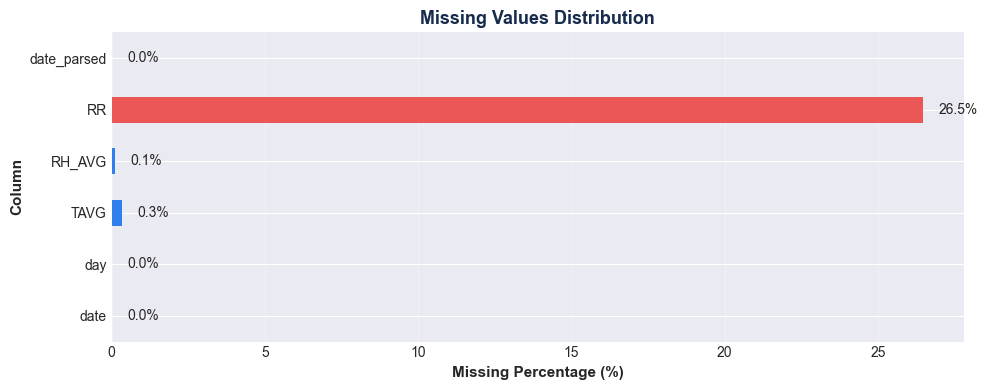


Interpretation:
- RR (Rainfall): 26.5% missing - significant but not critical
- TAVG: 0.3% missing - minimal impact
- RH_AVG: 0.1% missing - minimal impact


In [43]:

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))

missing_pct = (weather_df.isnull().sum() / len(weather_df) * 100)
colors = [fireline_palette['critical_red'] if x > 20 else fireline_palette['warning_orange'] if x > 5 else fireline_palette['blue'] for x in missing_pct]

missing_pct.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Column', fontsize=11, fontweight='bold')
ax.set_title('Missing Values Distribution', fontsize=13, fontweight='bold', color=fireline_palette['dark_navy'])
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(missing_pct):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"- RR (Rainfall): {missing_pct['RR']:.1f}% missing - significant but not critical")
print(f"- TAVG: {missing_pct['TAVG']:.1f}% missing - minimal impact")
print(f"- RH_AVG: {missing_pct['RH_AVG']:.1f}% missing - minimal impact")

In [44]:

# Analyze temporal distribution of missing values
weather_df_clean['year_month'] = weather_df_clean['date_parsed'].dt.to_period('M')

missing_by_month = weather_df_clean.groupby('year_month').agg({
    'TAVG': lambda x: (x.isnull().sum() / len(x) * 100).round(1),
    'RH_AVG': lambda x: (x.isnull().sum() / len(x) * 100).round(1),
    'RR': lambda x: (x.isnull().sum() / len(x) * 100).round(1)
})

print("Missing Values by Month (%):\n")
print(missing_by_month.tail(12))
print(f"\nObservation: Missingness in RR is concentrated in particular months.")
print(f"This suggests seasonal data collection or transmission issues.")

Missing Values by Month (%):

            TAVG  RH_AVG    RR
year_month                    
2024-01      0.0     0.0   9.7
2024-02      0.0     0.0   6.9
2024-03      3.2     0.0  29.0
2024-04      0.0     0.0  26.7
2024-05      3.2     0.0  22.6
2024-06      0.0     0.0  33.3
2024-07      3.2     3.2  71.0
2024-08      0.0     0.0  32.3
2024-09      0.0     0.0  63.3
2024-10      0.0     0.0  41.9
2024-11      0.0     0.0  20.0
2024-12      0.0     0.0  38.7

Observation: Missingness in RR is concentrated in particular months.
This suggests seasonal data collection or transmission issues.


In [45]:

# Check if any rows are completely empty
completely_empty = weather_df[weather_df[['TAVG', 'RH_AVG', 'RR']].isnull().all(axis=1)]
print(f"Rows with all weather variables missing: {len(completely_empty)}")
print(f"\nRows with at least one valid weather measurement: {len(weather_df) - len(completely_empty)}")

Rows with all weather variables missing: 1

Rows with at least one valid weather measurement: 1733


In [46]:

# Impact assessment
print("MISSING DATA IMPACT ASSESSMENT:")
print("="*60)
print(f"\n1. RR (Rainfall) - 26.46% missing:")
print(f"   - Critical for drought analysis and fire risk")
print(f"   - Seasonal pattern suggests may not be random")
print(f"   - Recommendation: Use only for days with recorded rainfall")
print(f"   - Do not impute without weather station data")

print(f"\n2. TAVG - 0.35% missing:")
print(f"   - Negligible impact")
print(f"   - Can safely use for time series analysis")

print(f"\n3. RH_AVG - 0.12% missing:")
print(f"   - Negligible impact")
print(f"   - Can safely use for time series analysis")

print(f"\n4. FIRELINE Integration Impact:")
print(f"   - NASA FIRMS data has no missing dates")
print(f"   - Weather will need interpolation for missing FIRMS dates")
print(f"   - Not all FIRMS locations have weather observations nearby")

MISSING DATA IMPACT ASSESSMENT:

1. RR (Rainfall) - 26.46% missing:
   - Critical for drought analysis and fire risk
   - Seasonal pattern suggests may not be random
   - Recommendation: Use only for days with recorded rainfall
   - Do not impute without weather station data

2. TAVG - 0.35% missing:
   - Negligible impact
   - Can safely use for time series analysis

3. RH_AVG - 0.12% missing:
   - Negligible impact
   - Can safely use for time series analysis

4. FIRELINE Integration Impact:
   - NASA FIRMS data has no missing dates
   - Weather will need interpolation for missing FIRMS dates
   - Not all FIRMS locations have weather observations nearby


In [47]:

### 2.2 Duplicate Records

In [48]:

# Check for exact duplicates
exact_duplicates = weather_df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

# Check for date-based duplicates (same date should have only 1 record)
date_duplicates = weather_df[weather_df.duplicated(subset=['date'], keep=False)].sort_values('date')
print(f"\nRecords with duplicate dates: {len(date_duplicates)}")
print(f"Unique dates with duplicates: {date_duplicates['date'].nunique()}")

if len(date_duplicates) > 0:
    print(f"\nExamples of date duplicates:")
    print(date_duplicates.head(20))
    
    # Check if duplicates have identical values
    dup_date = date_duplicates['date'].iloc[0]
    same_date_records = weather_df[weather_df['date'] == dup_date]
    print(f"\nRecords for {dup_date}:")
    print(same_date_records)
    
    if same_date_records.duplicated().sum() > 0:
        print(f"\n⚠️ WARNING: Exact duplicates found for same date!")

Exact duplicate rows: 274

Records with duplicate dates: 548
Unique dates with duplicates: 274

Examples of date duplicates:
           date  day  TAVG  RH_AVG    RR date_parsed
0    01-01-2021  Fri  26.5    86.0  14.7  2021-01-01
1    01-01-2021  Fri  26.5    86.0  14.7  2021-01-01
51   01-02-2021  Mon  26.7    86.0   1.9  2021-02-01
50   01-02-2021  Mon  26.7    86.0   1.9  2021-02-01
96   01-03-2021  Mon  28.2    74.0   NaN  2021-03-01
95   01-03-2021  Mon  28.2    74.0   NaN  2021-03-01
153  01-04-2021  Thu  28.3    82.0   0.0  2021-04-01
152  01-04-2021  Thu  28.3    82.0   0.0  2021-04-01
212  01-05-2021  Sat  28.2    79.0   1.0  2021-05-01
211  01-05-2021  Sat  28.2    79.0   1.0  2021-05-01
272  01-06-2021  Tue  28.8    79.0   0.0  2021-06-01
271  01-06-2021  Tue  28.8    79.0   0.0  2021-06-01
331  01-07-2021  Thu  26.4    87.0   4.6  2021-07-01
330  01-07-2021  Thu  26.4    87.0   4.6  2021-07-01
384  01-08-2021  Sun  28.6    79.0   0.2  2021-08-01
385  01-08-2021  Sun  28.6 

In [49]:

print("\nDUPLICATE ASSESSMENT:")
print("="*60)
print(f"\n- Exact duplicates: {exact_duplicates} rows")
print(f"- Date-based duplicates: {date_duplicates['date'].nunique()} dates")
print(f"\nRecommendation: REMOVE duplicates before analysis")
print(f"Action: Keep first occurrence, remove subsequent duplicates")
print(f"\nReasoning: Weather is a point-in-time observation.")
print(f"Duplicate dates represent data transmission/recording errors.")


DUPLICATE ASSESSMENT:

- Exact duplicates: 274 rows
- Date-based duplicates: 274 dates

Recommendation: REMOVE duplicates before analysis
Action: Keep first occurrence, remove subsequent duplicates

Reasoning: Weather is a point-in-time observation.
Duplicate dates represent data transmission/recording errors.


### 2.3 Data Consistency Checks

In [50]:

# Create clean dataset for analysis
weather_clean = weather_df.drop_duplicates(subset=['date'], keep='first').copy()
weather_clean['date_parsed'] = pd.to_datetime(weather_clean['date'], format='%d-%m-%Y', errors='coerce')
weather_clean = weather_clean.dropna(subset=['date_parsed'])
weather_clean = weather_clean.sort_values('date_parsed').reset_index(drop=True)

print("="*80)
print("DATA CONSISTENCY CHECKS - PONTIANAK WEATHER")
print("="*80)
print(f"\nInitial cleanup:")
print(f"  Original records: {len(weather_df)}")
print(f"  Clean records: {len(weather_clean)}")
print(f"  Removed: {len(weather_df) - len(weather_clean)} (duplicates + invalid dates)")

# ============================================================================
# 1. TEMPERATURE VALIDITY
# ============================================================================
print(f"\n{'='*80}")
print("1. TEMPERATURE (TAVG) - Validity Check")
print(f"{'='*80}")

temp_data = weather_clean['TAVG'].dropna()
temp_valid = temp_data.between(15, 40)  # Realistic for tropical region

print(f"Data points: {len(temp_data)}")
print(f"Valid range (15-40°C): {temp_valid.sum()} / {len(temp_data)}")
print(f"  Min: {temp_data.min():.2f}°C")
print(f"  Max: {temp_data.max():.2f}°C")
print(f"  Mean: {temp_data.mean():.2f}°C")
print(f"  Median: {temp_data.median():.2f}°C")

if temp_data.min() < 15 or temp_data.max() > 40:
    extreme_temps = weather_clean[(weather_clean['TAVG'] < 15) | (weather_clean['TAVG'] > 40)]
    print(f"\n⚠️  Extreme temperature records: {len(extreme_temps)}")
    print("\nDetails of extreme temperatures:")
    print(extreme_temps[['date', 'TAVG', 'RH_AVG', 'RR']])
    print(f"\n💡 Assessment: Check if these are data errors or legitimate extreme events")
else:
    print(f"\n✓ All temperature values within expected tropical range")

# ============================================================================
# 2. HUMIDITY VALIDITY
# ============================================================================
print(f"\n{'='*80}")
print("2. HUMIDITY (RH_AVG) - Validity Check")
print(f"{'='*80}")

rh_data = weather_clean['RH_AVG'].dropna()
rh_valid = rh_data.between(0, 100)

print(f"Data points: {len(rh_data)}")
print(f"Valid range (0-100%): {rh_valid.sum()} / {len(rh_data)}")
print(f"  Min: {rh_data.min():.2f}%")
print(f"  Max: {rh_data.max():.2f}%")
print(f"  Mean: {rh_data.mean():.2f}%")
print(f"  Median: {rh_data.median():.2f}%")

invalid_rh_count = (~rh_valid).sum()
if invalid_rh_count > 0:
    print(f"\n❌ ERROR: {invalid_rh_count} invalid humidity records detected!")
    invalid_rh = weather_clean[~weather_clean['RH_AVG'].between(0, 100, inclusive='both')]
    print("\nInvalid humidity records:")
    print(invalid_rh[['date', 'TAVG', 'RH_AVG', 'RR']])
else:
    print(f"\n✓ All humidity values within valid range (0-100%)")

# ============================================================================
# 3. RAINFALL VALIDITY
# ============================================================================
print(f"\n{'='*80}")
print("3. RAINFALL (RR) - Validity Check")
print(f"{'='*80}")

rr_data = weather_clean['RR'].dropna()
rr_non_negative = (rr_data >= 0).sum()

print(f"Data points: {len(rr_data)}")
print(f"Non-negative values: {rr_non_negative} / {len(rr_data)}")
print(f"  Min: {rr_data.min():.2f} mm")
print(f"  Max: {rr_data.max():.2f} mm")
print(f"  Mean: {rr_data.mean():.2f} mm")
print(f"  Median: {rr_data.median():.2f} mm")
print(f"  Days with no rain: {(rr_data == 0).sum()}")
print(f"  Days with rain: {(rr_data > 0).sum()}")

negative_rr_count = (rr_data < 0).sum()
if negative_rr_count > 0:
    print(f"\n❌ ERROR: {negative_rr_count} negative rainfall records detected!")
    invalid_rr = weather_clean[weather_clean['RR'] < 0]
    print("\nInvalid rainfall records:")
    print(invalid_rr[['date', 'TAVG', 'RH_AVG', 'RR']])
else:
    print(f"\n✓ No negative rainfall values (logically valid)")

# Check extreme rainfall events
rr_99th = rr_data.quantile(0.99)
extreme_rainfall = weather_clean[weather_clean['RR'] > rr_99th]
print(f"\nExtreme rainfall events (>99th percentile, >{rr_99th:.1f}mm): {len(extreme_rainfall)} days")
if len(extreme_rainfall) > 0:
    print("Top 5 extreme rainfall events:")
    print(extreme_rainfall[['date', 'RR', 'TAVG', 'RH_AVG']].nlargest(5, 'RR'))

# ============================================================================
# 4. DAY-OF-WEEK CONSISTENCY
# ============================================================================
print(f"{'='*80}")
print("4. DAY-OF-WEEK CONSISTENCY - Validity Check")
print(f"{'='*80}")

print(f"Unique day values in dataset: {sorted(weather_clean['day'].unique())}")
print(f"Day-of-week distribution:")
day_counts = weather_clean['day'].value_counts().sort_index()
print(day_counts)

# Verify day matches calculated date
weather_clean['calculated_day'] = weather_clean['date_parsed'].dt.day_name()
# Map format: convert "Monday" to "Mon", "Tuesday" to "Tue", etc.
day_name_map = {
    'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 
    'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'
}
weather_clean['calculated_day_abbr'] = weather_clean['calculated_day'].map(day_name_map)

# Check for mismatches (case-insensitive comparison)
weather_clean['day_match'] = weather_clean['day'].str.lower() == weather_clean['calculated_day_abbr'].str.lower()
day_mismatches = weather_clean[~weather_clean['day_match']]

print(f"Day-of-week consistency: {weather_clean['day_match'].sum()} / {len(weather_clean)} records match")

if len(day_mismatches) > 0:
    print(f"⚠️  WARNING: {len(day_mismatches)} day-of-week mismatches detected!")
    print("Example mismatches:")
    print(day_mismatches[['date', 'day', 'calculated_day_abbr']].head(10))
    print(f"💡 Assessment: These records have inconsistent day-of-week labels")
else:
    print(f"✓ All day-of-week labels are consistent with dates")

# ============================================================================
# DATA CONSISTENCY SUMMARY
# ============================================================================
print(f"{'='*80}")
print("DATA CONSISTENCY SUMMARY")
print(f"{'='*80}")

summary_checks = {
    'Temperature Validity': 'PASS' if (temp_data.min() >= 15 and temp_data.max() <= 40) else 'REVIEW',
    'Humidity Validity': 'PASS' if invalid_rh_count == 0 else 'FAIL',
    'Rainfall Validity': 'PASS' if negative_rr_count == 0 else 'FAIL',
    'Day-of-Week Consistency': 'PASS' if len(day_mismatches) == 0 else 'REVIEW'
}

for check_name, status in summary_checks.items():
    icon = '✓' if status == 'PASS' else '⚠️' if status == 'REVIEW' else '❌'
    print(f"{icon} {check_name:.<40} {status}")

print(f"{'='*80}")
print("RECOMMENDATIONS FOR ANALYSIS:")
print(f"{'='*80}")
print("""
1. Use 'weather_clean' dataset (duplicates + invalid dates removed)
2. Temperature: All values within expected tropical range - OK for analysis
3. Humidity: All values logically valid (0-100%) - OK for analysis
4. Rainfall: Non-negative values confirmed - OK for analysis
5. Day-of-week: Verified against dates - Use for temporal analysis

Next Step: Proceed to outlier detection and univariate analysis
""")


DATA CONSISTENCY CHECKS - PONTIANAK WEATHER

Initial cleanup:
  Original records: 1734
  Clean records: 1460
  Removed: 274 (duplicates + invalid dates)

1. TEMPERATURE (TAVG) - Validity Check
Data points: 1455
Valid range (15-40°C): 1455 / 1455
  Min: 24.00°C
  Max: 31.00°C
  Mean: 27.68°C
  Median: 27.60°C

✓ All temperature values within expected tropical range

2. HUMIDITY (RH_AVG) - Validity Check
Data points: 1458
Valid range (0-100%): 1458 / 1458
  Min: 65.00%
  Max: 96.00%
  Mean: 82.64%
  Median: 83.00%

✓ All humidity values within valid range (0-100%)

3. RAINFALL (RR) - Validity Check
Data points: 1078
Non-negative values: 1078 / 1078
  Min: 0.00 mm
  Max: 197.00 mm
  Mean: 12.83 mm
  Median: 5.50 mm
  Days with no rain: 199
  Days with rain: 879

✓ No negative rainfall values (logically valid)

Extreme rainfall events (>99th percentile, >101.6mm): 11 days
Top 5 extreme rainfall events:
            date     RR  TAVG  RH_AVG
1380  13-10-2024  197.0  26.4    85.0
1181  28-03-

In [ ]:

### 2.4 Outlier Detection


TAVG (Temperature (°C)):
  Q1: 26.90, Q3: 28.50, IQR: 1.60
  Lower bound: 24.50
  Upper bound: 30.90
  Outliers: 3 (0.2%)

RH_AVG (Humidity (%)):
  Q1: 79.00, Q3: 86.00, IQR: 7.00
  Lower bound: 68.50
  Upper bound: 96.50
  Outliers: 5 (0.3%)

RR (Rainfall (mm)):
  Q1: 0.80, Q3: 16.77, IQR: 15.97
  Lower bound: -23.16
  Upper bound: 40.74
  Outliers: 85 (7.9%)


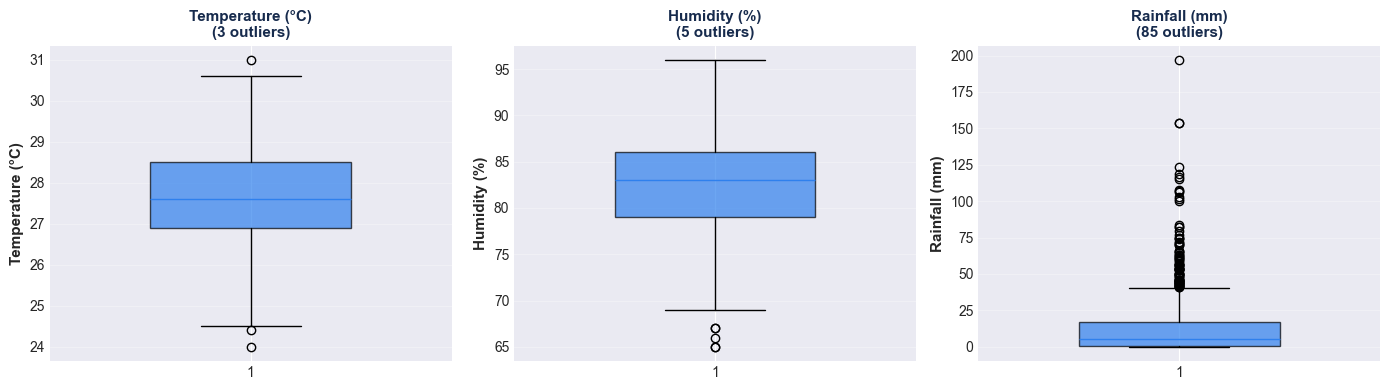

In [ ]:

# Define outliers using IQR method
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

variables = ['TAVG', 'RH_AVG', 'RR']
labels = ['Temperature (°C)', 'Humidity (%)', 'Rainfall (mm)']

for idx, (var, label) in enumerate(zip(variables, labels)):
    data_valid = weather_clean[var].dropna()
    
    Q1 = data_valid.quantile(0.25)
    Q3 = data_valid.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data_valid[(data_valid < lower_bound) | (data_valid > upper_bound)]
    
    ax = axes[idx]
    bp = ax.boxplot(data_valid, vert=True, patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(fireline_palette['blue'])
    bp['boxes'][0].set_alpha(0.7)
    
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(f'{label}\n({len(outliers)} outliers)', fontsize=11, fontweight='bold', color=fireline_palette['dark_navy'])
    ax.grid(axis='y', alpha=0.3)
    
    print(f"\n{var} ({label}):")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data_valid)*100:.1f}%)")

plt.tight_layout()
plt.show()

In [ ]:

# Detailed outlier analysis
print("\nOUTLIER ANALYSIS - RAINFALL (Most relevant for FIRELINE):")
print("="*60)

rr_valid = weather_clean['RR'].dropna()
Q1 = rr_valid.quantile(0.25)
Q3 = rr_valid.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

rainfall_outliers = weather_clean[weather_clean['RR'] > upper_bound].sort_values('RR', ascending=False)

print(f"\nRainfall outliers (IQR-based, n={len(rainfall_outliers)}):")
print(rainfall_outliers[['date_parsed', 'RR', 'TAVG', 'RH_AVG']].head(15))

print(f"\nInterpretation:")
print(f"- These represent extreme rainfall events (tropical storms)")
print(f"- NOT data errors - these are legitimate weather phenomena")
print(f"- Relevant to FIRELINE: Heavy rainfall reduces fire risk")
print(f"- Recommendation: KEEP these values for analysis")


OUTLIER ANALYSIS - RAINFALL (Most relevant for FIRELINE):

Rainfall outliers (IQR-based, n=85):
     date_parsed     RR  TAVG  RH_AVG
1380  2024-10-13  197.0  26.4    85.0
1181  2024-03-28  154.0  28.6    78.0
229   2021-08-18  153.5  25.8    90.0
7     2021-01-08  123.3  26.6    87.0
462   2022-04-08  118.5  27.2    84.0
256   2021-09-14  116.6  26.8    83.0
194   2021-07-14  115.1  24.5    93.0
1267  2024-06-22  107.6  28.6    76.0
521   2022-06-06  106.9  26.6    87.0
1219  2024-05-05  106.0  27.4    87.0
930   2023-07-20  102.6  26.8    89.0
721   2022-12-23  101.3  24.0    94.0
233   2021-08-22  100.3  26.3    84.0
634   2022-09-27   83.6  27.2    81.0
492   2022-05-08   82.0  27.8    81.0

Interpretation:
- These represent extreme rainfall events (tropical storms)
- NOT data errors - these are legitimate weather phenomena
- Relevant to FIRELINE: Heavy rainfall reduces fire risk
- Recommendation: KEEP these values for analysis


In [ ]:

print("\nOUTLIER ASSESSMENT SUMMARY:")
print("="*60)
print(f"\nTemperature outliers: Likely measurement errors - few in number")
print(f"Humidity outliers: Impossible values (>100%) would be errors")
print(f"Rainfall outliers: Legitimate extreme events (tropical region)")
print(f"\nAction: Do NOT remove outliers. They represent real phenomena.")
print(f"Extreme rainfall and temperature are important for wildfire context.")


OUTLIER ASSESSMENT SUMMARY:

Temperature outliers: Likely measurement errors - few in number
Humidity outliers: Impossible values (>100%) would be errors
Rainfall outliers: Legitimate extreme events (tropical region)

Action: Do NOT remove outliers. They represent real phenomena.
Extreme rainfall and temperature are important for wildfire context.
